# Лабораторная работа 4
# Правильный многоугольник Рело. Векторизация вычислений в numpy

### Основные определения
**Треугольник Рело** представляет собой область пересечения трех кругов радуса с
центрами в вершинах равностороннего треугольника с длиной стороны $r$.

**Правильный $n$-угольник Рело** представляет собой область пересечения кругов $n$
радуса $r$ с центрами в вершинах правильного $n$ -угольника с нечетным числом
сторон длины $l$ . Радиус $r$ круга согласован с длиной $l$ стороны правильного
многоугольника таким образом, чтобы окружность радиуса $r$ с центром в вершине
правильного $n$-угольника проходила через две соседние вершины правильного
$n$-угольника, противолежащие центру

**Опорные прямые фигуры** -- это две параллельные прямые, которые касаются
фигуры, но не пересекают ее.

**Фигура постоянной ширины** -- это геометрическая фигура, для которой
расстояние между любыми опорными прямыми будет всегда одинаковым.
Расстояние между опорными прямыми называется **шириной фигуры**.

## Задание 4.1. Построение треугольника Рело

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
n = 3 # количество вершин треугольника Рело
center = np.array([0,0]) # координаты центра треугольника Рело
r = 10. # ширина треугольника Рело
N = 100 # количество точек для описания одной стороны треугольника Рело

### Этап 1. Вычисление координат вершин правильного треугольника
Радиус окружности $R$, описанной вокруг правильного $n$
-угольника с длиной стороны $l$, вычисляется по формуле: 
$$R=\frac{l}{2sin(\pi /n)}$$
Длина стороны $l$ правильного треугольника, на котором будем строить треугольник
Рело, совпадает с шириной треугольника Рело $r$.

In [3]:
l = r # равенство справедливо только для треугольника Рело

In [4]:
R = l/(2*np.sin(np.pi/n))
print(R)

5.773502691896258


Зафиксируем прямоугольную декартову систему координат. Центр треугольника
размещаем в точке center. Построим матрицу vertices с координатами
вершин правильного треугольника, используя параметрическое описание точек описанной окружности по формуле $$x(t)=x_0+Rcos(t)$$ $$y(t)=y_0+Rsin(t)$$ для
значений $ t \in \{0,  2\pi/3 , 4\pi/3 \}$

In [5]:
t = np.arange(0,2*np.pi,2*np.pi/n)
vertices = center + R*np.transpose([np.cos(t), np.sin(t)])
vertices

array([[ 5.77350269,  0.        ],
       [-2.88675135,  5.        ],
       [-2.88675135, -5.        ]])

In [6]:
print(vertices[0,0])

5.773502691896258


In [7]:
vertices[0,0], vertices[0,:], vertices[:,1]

(np.float64(5.773502691896258),
 array([5.77350269, 0.        ]),
 array([ 0.,  5., -5.]))

In [8]:
vertices[:,0]

array([ 5.77350269, -2.88675135, -2.88675135])

(np.float64(-3.3197640478403514),
 np.float64(6.206515393788478),
 np.float64(-5.499999999999999),
 np.float64(5.500000000000001))

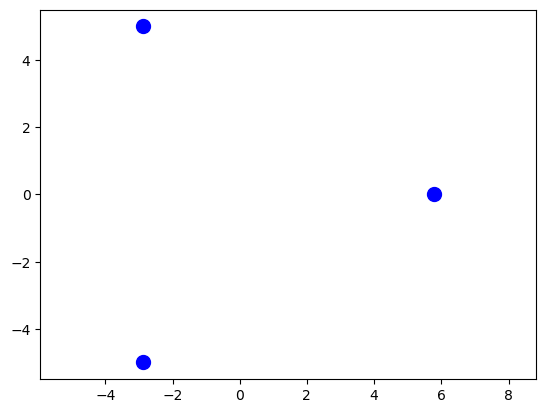

In [9]:
plt.plot(vertices[:,0],vertices[:,1],'b.',markersize=20)
plt.axis('equal')

### Этап 2. Представление одной стороны треугольника Рело

Обозначим через $\alpha$ центральный угол, соответствующий стороне правильног
-угольника. Тогда: $$\alpha=2\pi/n$$
Обозначим через $\beta$ центральный угол, соответствующий стороне правильного
многоугольника Рело, когда центр окружности расположен в вершине правильного
многоугольника. Тогда:$$\beta=\alpha/2$$
Необходимо построить матрицу с координатами точек, описывающих одну сторону
треугольника Рело относительно вершины vertices[0] . Сторона представляет
собой дугу окружности радиуса с центром в точке vertices[0] и значением
угла $[\pi-\beta/2;\pi+\beta/2]$

In [10]:
alpha = 2*np.pi/n
beta = alpha/2

Вычислим массив angle значений угла для построения координат точек стороны
треугольника Рело, состоящий из N элементов


In [11]:
angle = np.linspace(-beta/2, beta/2, N)

In [12]:
print(angle)

[-0.52359878 -0.51302102 -0.50244327 -0.49186552 -0.48128776 -0.47071001
 -0.46013226 -0.4495545  -0.43897675 -0.428399   -0.41782125 -0.40724349
 -0.39666574 -0.38608799 -0.37551023 -0.36493248 -0.35435473 -0.34377697
 -0.33319922 -0.32262147 -0.31204371 -0.30146596 -0.29088821 -0.28031046
 -0.2697327  -0.25915495 -0.2485772  -0.23799944 -0.22742169 -0.21684394
 -0.20626618 -0.19568843 -0.18511068 -0.17453293 -0.16395517 -0.15337742
 -0.14279967 -0.13222191 -0.12164416 -0.11106641 -0.10048865 -0.0899109
 -0.07933315 -0.06875539 -0.05817764 -0.04759989 -0.03702214 -0.02644438
 -0.01586663 -0.00528888  0.00528888  0.01586663  0.02644438  0.03702214
  0.04759989  0.05817764  0.06875539  0.07933315  0.0899109   0.10048865
  0.11106641  0.12164416  0.13222191  0.14279967  0.15337742  0.16395517
  0.17453293  0.18511068  0.19568843  0.20626618  0.21684394  0.22742169
  0.23799944  0.2485772   0.25915495  0.2697327   0.28031046  0.29088821
  0.30146596  0.31204371  0.32262147  0.33319922  0.

In [13]:
side0 = vertices[0] + r*np.transpose([np.cos(np.pi + angle),
 np.sin(np.pi + angle)])

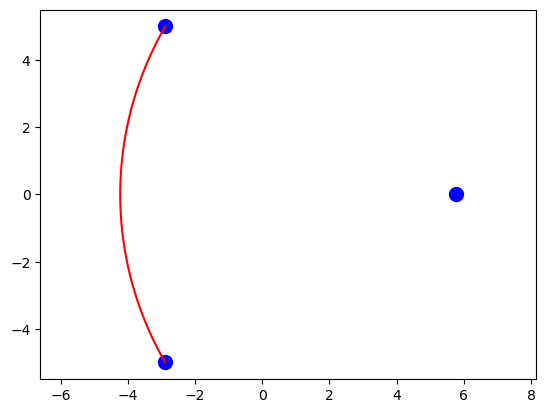

In [14]:
plt.plot(vertices[:,0],vertices[:,1],'b.',markersize=20)
plt.plot(side0[:,0],side0[:,1],'r-',markersize=20)
plt.axis('equal');

In [15]:
side1 = vertices[1] + r*np.transpose([np.cos(np.pi + angle + alpha),
 np.sin(np.pi + angle + alpha)])

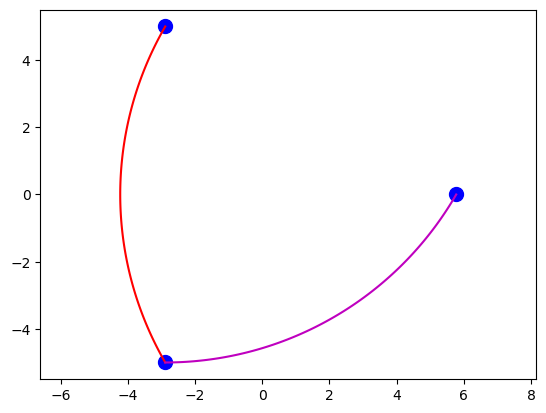

In [16]:
plt.plot(vertices[:,0],vertices[:,1],'b.',markersize=20)
plt.plot(side0[:,0],side0[:,1],'r-',markersize=20)
plt.plot(side1[:,0],side1[:,1],'m-',markersize=20)
plt.axis('equal');

In [23]:
side2 = vertices[2] + r*np.transpose([np.cos(np.pi + angle + 2*alpha),
 np.sin(np.pi + angle + 2*alpha)])

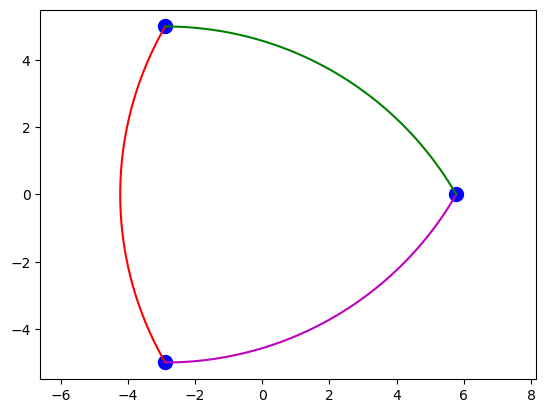

In [25]:
plt.plot(vertices[:,0],vertices[:,1],'b.',markersize=20)
plt.plot(side0[:,0],side0[:,1],'r-',markersize=20)
plt.plot(side1[:,0],side1[:,1],'m-',markersize=20)
plt.plot(side2[:,0],side2[:,1],'g-',markersize=20)
plt.axis('equal');

### Этап 3. Моделирование границы треугольника Рело

In [20]:
list_sides = [vertices[i] +
 r*np.transpose([np.cos(angle + np.pi + i*alpha),
 np.sin(angle + np.pi + i*alpha)])
 for i in range(n)]

In [21]:
sides = np.concatenate(list_sides)

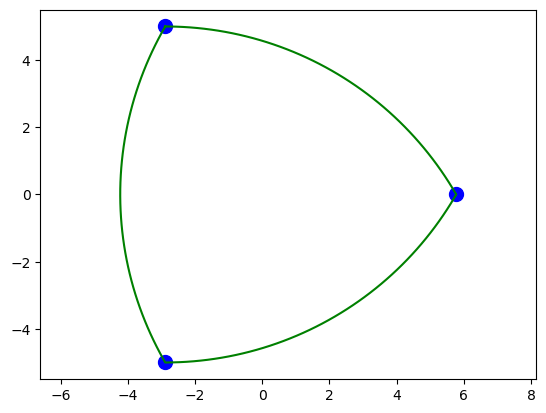

In [22]:
plt.plot(vertices[:,0],vertices[:,1],'b.',markersize=20)
plt.plot(sides[:,0],sides[:,1],'g-',markersize=20)
plt.axis('equal');

## Задание 4.2. Построение правильного многоугольника Рело

$$
r^2 = 2R^2 - 2R^2 \cos\left(\frac{2\pi}{n} \cdot \frac{n-1}{2}\right) = 2R^2 \left(1 - \cos\left(\frac{\pi(n-1)}{n}\right)\right)
$$

$$
= 2R^2 \left(1 - \cos\left(\pi - \frac{\pi}{n}\right)\right) = 2R^2 \left(1 + \cos\frac{\pi}{n}\right) = 4R^2 \cos^2\frac{\pi}{2n} \Rightarrow
$$

$$
r = 2R \cos\frac{\pi}{2n} = 2 \left( \frac{l}{2\sin\frac{\pi}{n}} \right) \cos\frac{\pi}{2n} = \frac{l}{2\sin\frac{\pi}{2n}}
$$

$$
l = 2r \sin\frac{\pi}{2n}
$$

In [26]:
n1 = 5 
center = np.array([0,0])
r = 10. 
N = 100

In [28]:
l1 = 2 * r * np.sin(np.pi / (2 * n1))
print(l1)                    

6.180339887498948


In [29]:
R1 = l1/(2*np.sin(np.pi/n1))
print(R1)

5.257311121191336


In [30]:
t = np.arange(0,2*np.pi,2*np.pi/n1)
vertices = center + R1*np.transpose([np.cos(t), np.sin(t)])
vertices

array([[ 5.25731112,  0.        ],
       [ 1.62459848,  5.        ],
       [-4.25325404,  3.09016994],
       [-4.25325404, -3.09016994],
       [ 1.62459848, -5.        ]])

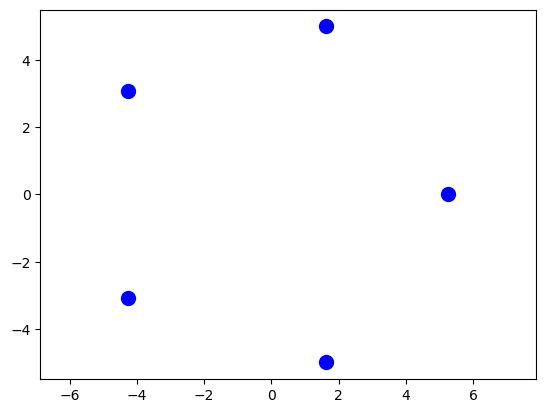

In [32]:
plt.plot(vertices[:,0],vertices[:,1],'b.',markersize=20)
plt.axis('equal');

In [33]:
alpha = 2*np.pi/n1
beta = alpha/2

In [34]:
angle = np.linspace(-beta/2, beta/2, N)

In [36]:
list_sides = [vertices[i] +
 r*np.transpose([np.cos(angle + np.pi + i*alpha),
 np.sin(angle + np.pi + i*alpha)])
 for i in range(n1)]

In [37]:
sides = np.concatenate(list_sides)

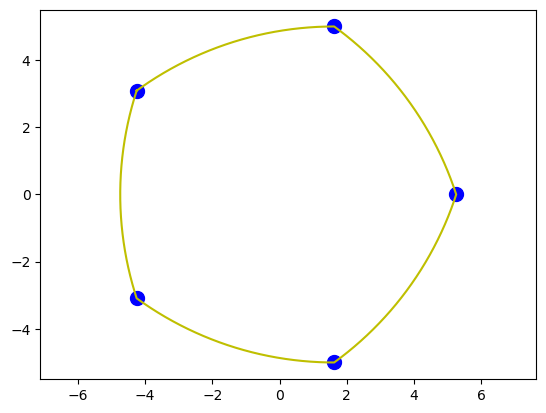

In [50]:
plt.plot(vertices[:,0],vertices[:,1],'b.',markersize=20)
plt.plot(sides[:,0],sides[:,1],'y-',markersize=20)
plt.axis('equal');

## Задание 4.3. Результирующая пользовательская функция

In [52]:
def regular_polygon_Relo(
    n: int = 3,
    center= None,
    r: float = 1.0,
    N: int = 100
) -> np.ndarray:
    """
    Возвращает матрицу координат границы правильного n-угольника Рело.

    Параметры
    ---------
    n : int, default=3
        Количество вершин правильного многоугольника Рело.
        Должно быть нечётным целым числом, большим 2.
    center : np.ndarray, default=np.array([0, 0])
        Массив координат центра фигуры [x0, y0].
    r : float, default=1.0
        Ширина правильного многоугольника Рело (положительное число).
    N : int, default=100
        Количество точек для описания одной стороны (натуральное число).

    Возвращает
    ----------
    sides : np.ndarray
        Матрица размера (N*n, 2), каждая строка содержит координаты (x, y)
        точки границы правильного многоугольника Рело.
    """
    # Контроль значений аргументов с помощью assert
    assert isinstance(n, int), "n должно быть целым числом"
    assert n > 2, "n должно быть больше 2"
    assert n % 2 == 1, "n должно быть нечётным"

    if center is None:
        center = np.array([0, 0])
    assert isinstance(center, np.ndarray), "center должен быть массивом numpy"
    assert center.shape == (2,), "center должен иметь размерность (2,)"

    assert isinstance(r, (int, float)), "r должно быть числом"
    assert r > 0, "r должно быть положительным"

    assert isinstance(N, int), "N должно быть целым числом"
    assert N > 0, "N должно быть натуральным числом"

    l = 2 * r * np.sin(np.pi / (2 * n))
    R = l / (2 * np.sin(np.pi / n))
    
    alpha = 2 * np.pi / n
    t = np.arange(0, 2 * np.pi, alpha)
    vertices = center + R * np.transpose([np.cos(t), np.sin(t)])
    beta = alpha / 2
    angle = np.linspace(-beta / 2, beta / 2, N)

    list_sides = [
        vertices[i] + r * np.transpose([
            np.cos(np.pi + angle + i * alpha),
            np.sin(np.pi + angle + i * alpha)
        ])
        for i in range(n)
    ]
    
    sides = np.concatenate(list_sides)
    
    return sides

In [54]:
print(regular_polygon_Relo.__annotations__)

{'n': <class 'int'>, 'r': <class 'float'>, 'N': <class 'int'>, 'return': <class 'numpy.ndarray'>}


In [55]:
print(regular_polygon_Relo.__doc__)


Возвращает матрицу координат границы правильного n-угольника Рело.

Параметры
---------
n : int, default=3
    Количество вершин правильного многоугольника Рело.
    Должно быть нечётным целым числом, большим 2.
center : np.ndarray, default=np.array([0, 0])
    Массив координат центра фигуры [x0, y0].
r : float, default=1.0
    Ширина правильного многоугольника Рело (положительное число).
N : int, default=100
    Количество точек для описания одной стороны (натуральное число).

Возвращает
----------
sides : np.ndarray
    Матрица размера (N*n, 2), каждая строка содержит координаты (x, y)
    точки границы правильного многоугольника Рело.



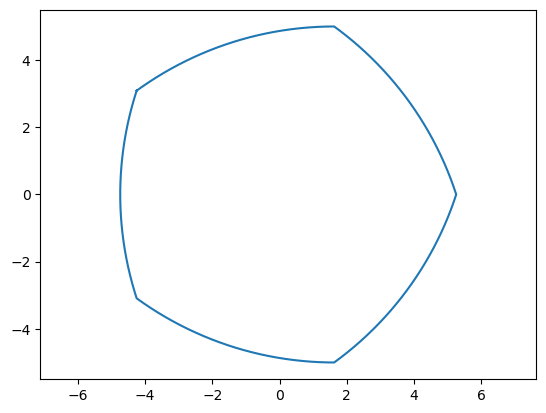

In [57]:
sides = regular_polygon_Relo(5, None, 10, 100)
plt.plot(sides[:,0], sides[:,1])
plt.axis('equal');

## Задание 4.3. Результирующая пользовательская функция

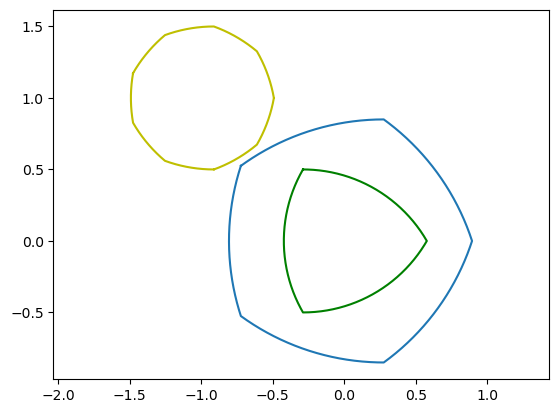

In [63]:
sides1 = regular_polygon_Relo(9,np.array([-1,1]), 1, 100)
sides2 = regular_polygon_Relo(3, None, 1, 100)
sides3 = regular_polygon_Relo(5, None, 1.7, 100)
plt.plot(sides1[:,0], sides1[:,1],'y-')
plt.plot(sides2[:,0], sides2[:,1],'g-')
plt.plot(sides3[:,0], sides3[:,1])
plt.axis('equal');

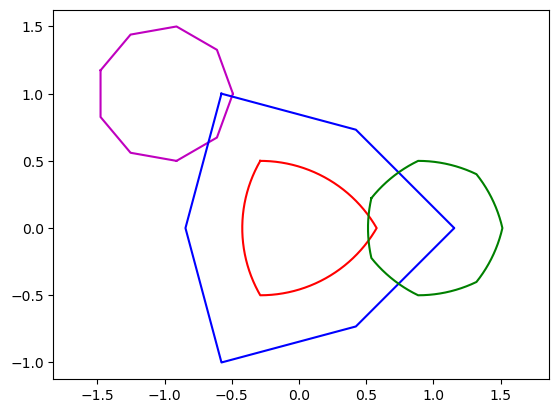

In [66]:
Relo1 = regular_polygon_Relo(9,np.array([-1,1]),1,2)
plt.plot(Relo1[:,0],Relo1[:,1],'m-')

Relo2 = regular_polygon_Relo(3,None,2,3)
plt.plot(Relo2[:,0],Relo2[:,1],'b-')

Relo3 = regular_polygon_Relo(3,None,1,100)
plt.plot(Relo3[:,0],Relo3[:,1],'r-')

Relo4 = regular_polygon_Relo(7,np.array([1,0]),1,100)
plt.plot(Relo4[:,0],Relo4[:,1],'g-')

plt.axis('equal');